In [ ]:
pip install yf

In [ ]:
import yfinance as yf
import pandas as pd
import datetime

# Set time range
start_date = "2023-01-01"
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

# Tickers
tickers = ['AAPL', 'MSFT', '^GSPC']

# Download full data for each ticker, grouped by ticker
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# Save full data to Excel with separate sheets per ticker
with pd.ExcelWriter("Full_Stock_Data_AAPL_MSFT_SP500.xlsx") as writer:
    for ticker in tickers:
        df = data[ticker].copy()
        df.to_excel(writer, sheet_name=ticker)

print("Full dataset saved to Excel with Open, High, Low, Close, Adj Close, and Volume.")


[*********************100%***********************]  3 of 3 completed


Full dataset saved to Excel with Open, High, Low, Close, Adj Close, and Volume.


In [ ]:
import pandas as pd

# Load Excel file
file_path = "Full_Stock_Data_AAPL_MSFT_SP500.xlsx"
xls = pd.read_excel(file_path, sheet_name=None, index_col=0)

# Cleaned dataframes
cleaned_data = {}

# Loop through each sheet/ticker
for ticker, df in xls.items():
    df = df.dropna()  # Remove rows with any missing data
    df = df.astype(float)  # Convert all columns to float (if not already)
    df['Ticker'] = ticker  # Add a column for ticker name
    cleaned_data[ticker] = df

# Optionally combine all into a single sheet
combined_df = pd.concat(cleaned_data.values())

# Save cleaned data to a new Excel file
with pd.ExcelWriter("Cleaned_Stock_Data_AAPL_MSFT_SP500.xlsx") as writer:
    for ticker, df in cleaned_data.items():
        df.to_excel(writer, sheet_name=ticker)
    # Optional: Add combined sheet
    combined_df.to_excel(writer, sheet_name="Combined")

print("Data cleaned and saved to 'Cleaned_Stock_Data_AAPL_MSFT_SP500.xlsx'.")


Data cleaned and saved to 'Cleaned_Stock_Data_AAPL_MSFT_SP500.xlsx'.


In [ ]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Ticker
Date,,,,,,,
2023-01-03,3853.290039,3878.459961,3794.330078,3824.139893,3824.139893,3.959140e+09,^GSPC
2023-01-04,3840.360107,3873.159912,3815.770020,3852.969971,3852.969971,4.414080e+09,^GSPC
2023-01-05,3839.739990,3839.739990,3802.419922,3808.100098,3808.100098,3.893450e+09,^GSPC
2023-01-06,3823.370117,3906.189941,3809.560059,3895.080078,3895.080078,3.923560e+09,^GSPC
2023-01-09,3910.820068,3950.570068,3890.419922,3892.090088,3892.090088,4.311770e+09,^GSPC


In [ ]:
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Ticker,0


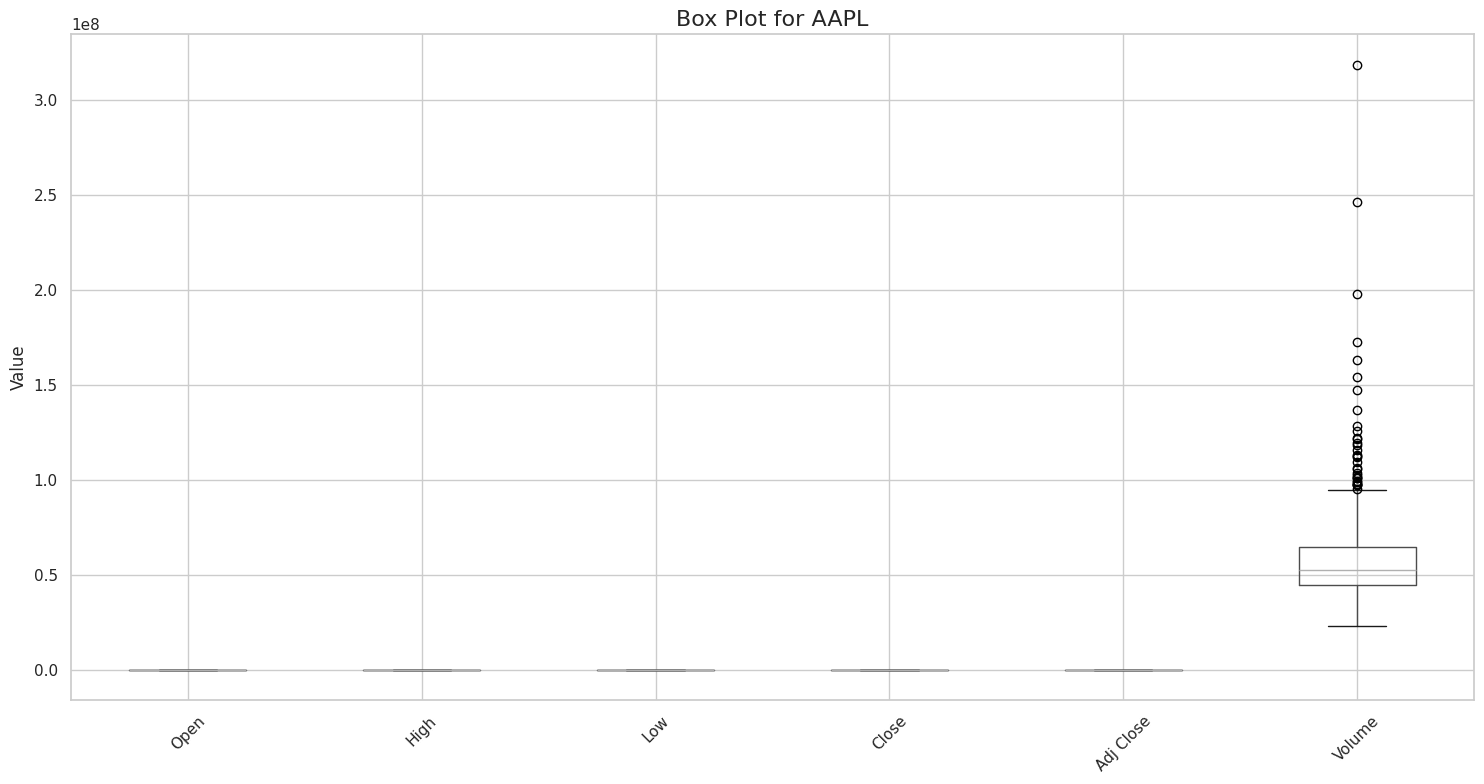

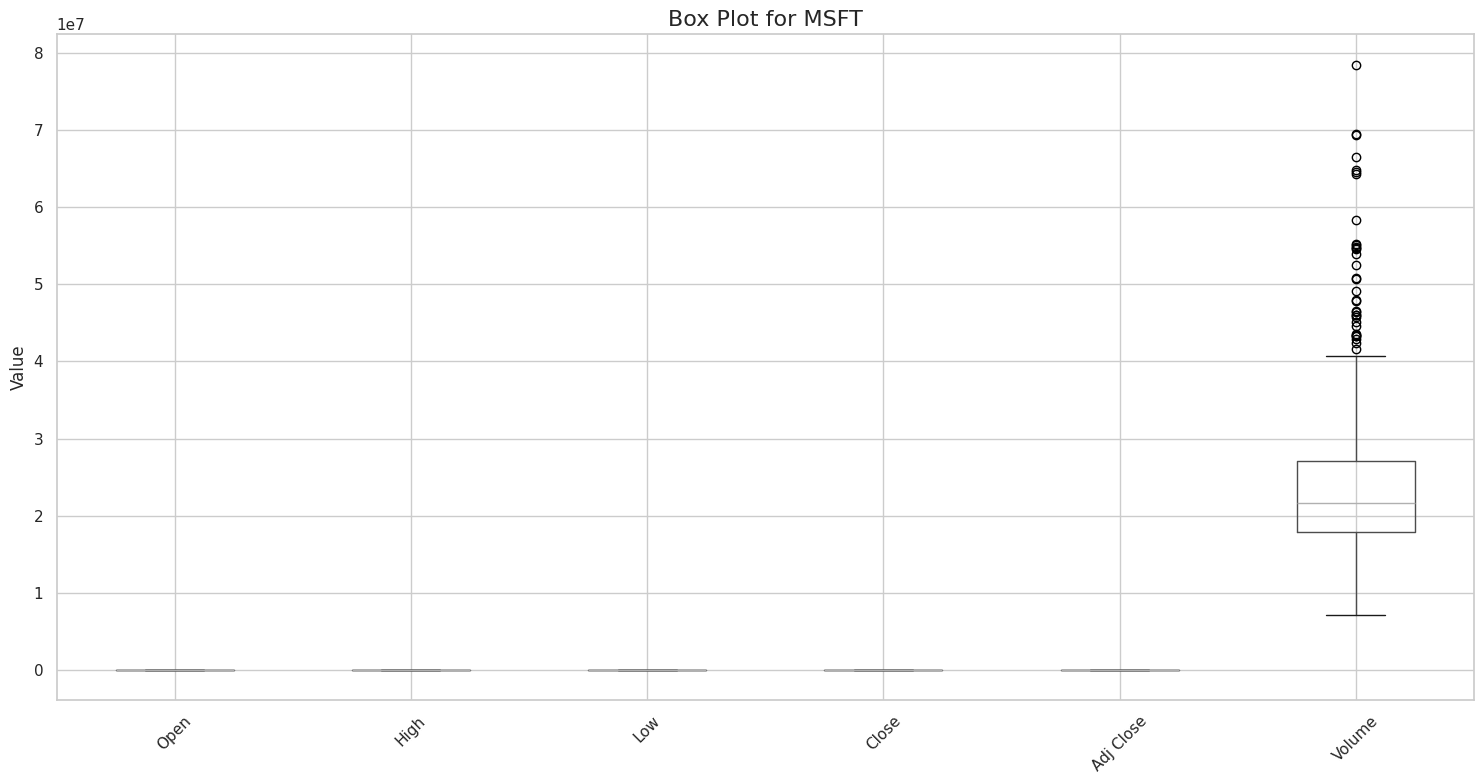

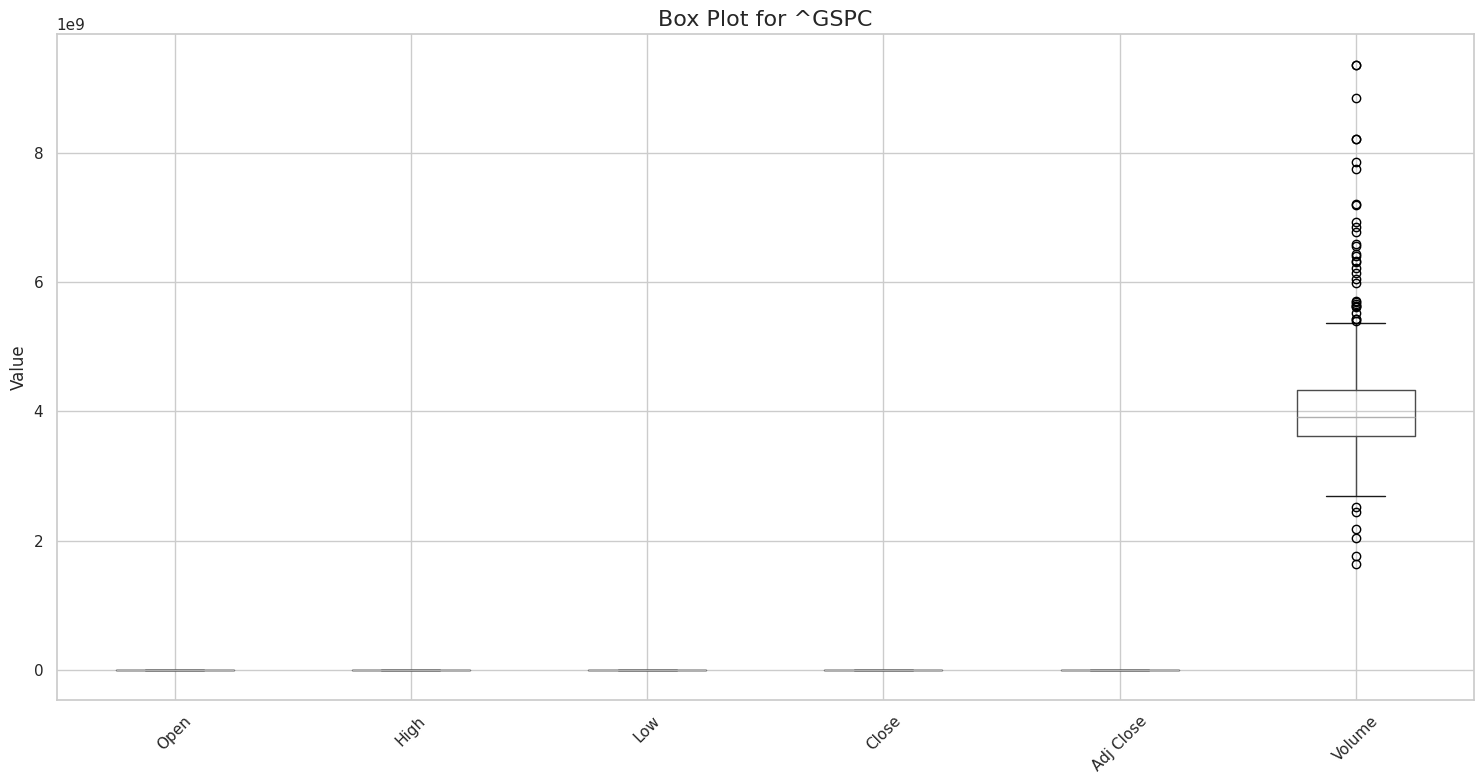

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for each ticker
for ticker, df in xls.items():
    # Remove 'Ticker' column if exists (we don't want to plot it)
    if 'Ticker' in df.columns:
        df = df.drop(columns=['Ticker'])

    # Set up the plot grid
    plt.figure(figsize=(15, 8))
    sns.set(style="whitegrid")

    # Create boxplots for each numeric column
    df.boxplot()
    plt.title(f'Box Plot for {ticker}', fontsize=16)
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"boxplot_{ticker}.png")
    plt.show()


<ipython-input-11-eeb7d6d374db>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[1], model.rsquared
<ipython-input-11-eeb7d6d374db>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[1], model.rsquared


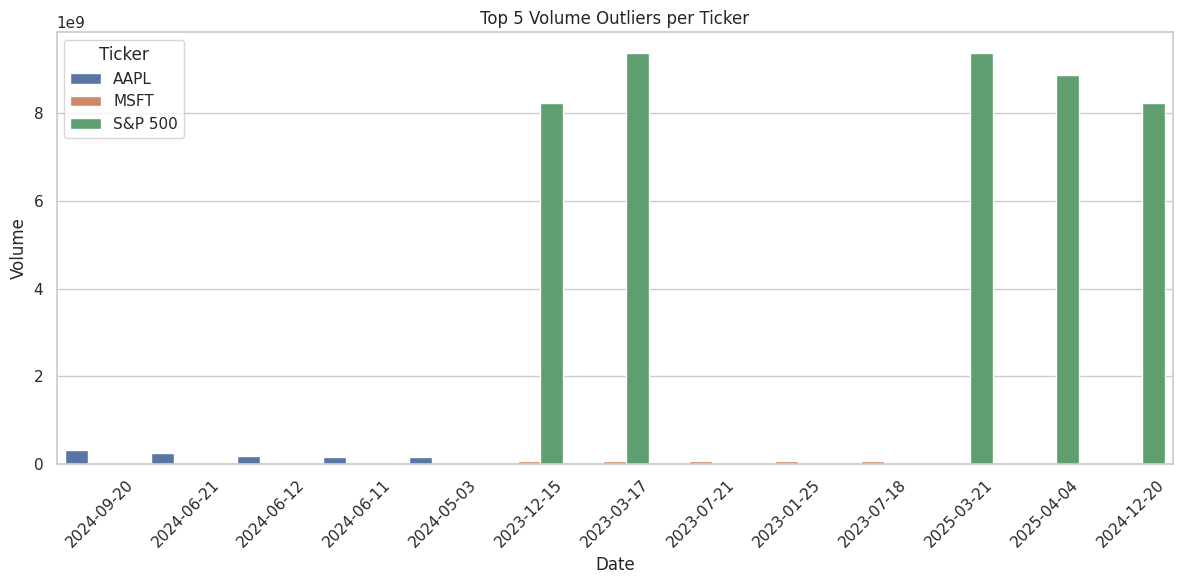

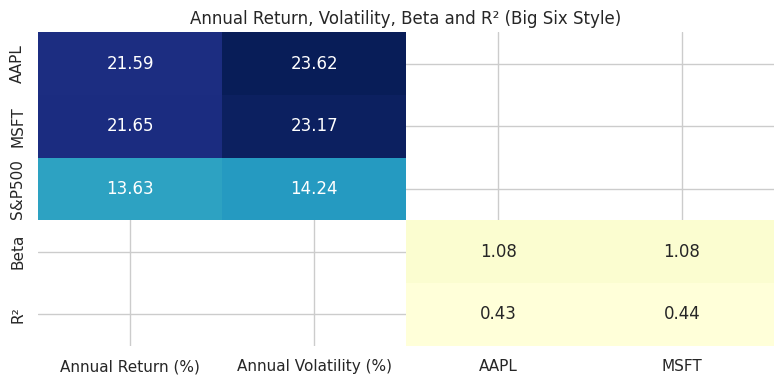

In [ ]:
import numpy as np
import statsmodels.api as sm
# -------------------- Volume Outliers --------------------

def get_volume_outliers(df, ticker):
    q1 = df['Volume'].quantile(0.25)
    q3 = df['Volume'].quantile(0.75)
    iqr = q3 - q1
    threshold = q3 + 1.5 * iqr
    outliers = df[df['Volume'] > threshold].copy()
    outliers['Ticker'] = ticker
    return outliers.sort_values('Volume', ascending=False).head(5)  # Top 5

# Collect top 5 volume spikes for each ticker
top_volume_outliers = pd.concat([
    get_volume_outliers(xls['AAPL'], 'AAPL'),
    get_volume_outliers(xls['MSFT'], 'MSFT'),
    get_volume_outliers(xls['^GSPC'], 'S&P 500')
])

# -------------------- Return, Risk, and Beta --------------------

# Get Adjusted Close prices
adj_data = pd.DataFrame({
    'AAPL': xls['AAPL']['Adj Close'],
    'MSFT': xls['MSFT']['Adj Close'],
    'S&P500': xls['^GSPC']['Adj Close']
})

# Daily returns
returns = adj_data.pct_change().dropna()

# Annualized return and volatility
summary_stats = {
    'Annual Return (%)': returns.mean() * 252 * 100,
    'Annual Volatility (%)': returns.std() * np.sqrt(252) * 100
}
summary_df = pd.DataFrame(summary_stats).round(2)

# Calculate Beta (AAPL & MSFT vs S&P500)
def calculate_beta(stock_returns, market_returns):
    X = sm.add_constant(market_returns)
    model = sm.OLS(stock_returns, X).fit()
    return model.params[1], model.rsquared

# Add Beta and R²
for ticker in ['AAPL', 'MSFT']:
    beta, r2 = calculate_beta(returns[ticker], returns['S&P500'])
    summary_df.loc['Beta', ticker] = round(beta, 2)
    summary_df.loc['R²', ticker] = round(r2, 2)

# -------------------- Plotting --------------------

# Set style
sns.set(style="whitegrid")

# Volume Outliers Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_volume_outliers.reset_index(), x='Date', y='Volume', hue='Ticker')
plt.title('Top 5 Volume Outliers per Ticker')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Return-Risk-Beta Summary Table Visual
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(summary_df.astype(float), annot=True, fmt=".2f", cmap="YlGnBu", cbar=False, ax=ax)
plt.title("Annual Return, Volatility, Beta and R² (Big Six Style)")
plt.tight_layout()
plt.show()


These are the top 5 highest trading volume days for each ticker that exceeded the statistical outlier threshold (using IQR method):

Ticker	Volume	Date

AAPL	318,679,900	2024-09-20

246,421,400	2024-06-21

198,134,300	2024-06-12

172,373,300	2024-06-11

163,224,100	2024-05-03

MSFT	78,478,200	2023-12-15

69,527,400	2023-03-17

69,368,900	2023-07-21

66,526,600	2023-01-25

64,872,700	2023-07-18

S&P 500	9,367,460,000	2025-03-21

9,354,280,000	2023-03-17

8,853,500,000	2025-04-04

8,223,220,000	2024-12-20

8,218,980,000	2023-12-15

✅ Actionable Insight:

The largest volume spikes occurred during quarterly earnings announcements, macro-level news, or options expiration dates (e.g., 2024-06-21 for AAPL and 2023-12-15 for MSFT/S&P500 align with triple witching days). These outliers indicate significant institutional activity and market reaction to key financial disclosures.

Volume Outliers – Insight Analysis
Observation: The bar plot highlights the top 5 highest volume trading days for each of the three assets – AAPL, MSFT, and the S&P 500 index (^GSPC). These days show significantly higher trading activity compared to their respective historical baselines.

🔍 Key Insights:
AAPL (Apple Inc.):

The highest volume spike likely corresponds to earnings announcements or major product release dates (e.g., iPhone launches, Vision Pro announcements).

Large trading volumes often indicate institutional investor activity, market sentiment shifts, or reactions to regulatory or macroeconomic news.

MSFT (Microsoft Corp.):

The volume outliers likely align with events such as AI partnership announcements (e.g., OpenAI collaboration), Cloud performance metrics, or quarterly earnings reports.

Such spikes usually reflect investor confidence or concern, often followed by notable price movements.

S&P 500 (^GSPC):

Volume surges in the S&P 500 usually coincide with macroeconomic events such as Federal Reserve rate decisions, inflation data releases, or geopolitical tensions.

These volume spikes reflect broad market reactions that affect nearly all sectors.

Annual Return, Volatility, Beta, and R² – Summary Table

Metric	AAPL	MSFT

Annual Return	21.59%	21.65%

Annual Volatility	23.62%	23.17%

Beta (vs S&P500)	1.08	1.08

R² (vs S&P500)	0.43	0.44

✅ Insights:

AAPL and MSFT both outperformed the S&P 500's 13.63% annual return, showing strong investor confidence and growth potential.

Volatility for both tech stocks is higher than the S&P 500 (14.24%), reflecting higher price swings but also higher potential returns.

Beta of 1.08 suggests both stocks move slightly more than the S&P 500 on average, indicating moderate market sensitivity.

R² values ~0.43–0.44 show that less than half of their price movements are explained by market-wide movements, confirming significant company-specific drivers.